<a href="https://colab.research.google.com/github/laumac/ALPR_Testing_Analysis/blob/main/PANDAS_ALPR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Välkommen till Colab!

## **Analysis of algorithms for automatic license plate recognition**

**Goal:** Evaluation of system precision in vehicle identification under various environmental conditions (lighting, angles).

**Methodology:** Generated 1,000 synthetic test cases to simulate real-world scenarios.

**Project:** Analysis of ALPR Algorithm Precision

**Objective:** To evaluate ALPR algorithm precision under varying environmental conditions.

**Overall Performance:** The system achieved an aggregate accuracy of   47.60 % across all 1,000 test cases.

**Key Finding 1:** The system maintains 100% accuracy in optimal lighting (Sunny).

**Key Finding 2:** System reliability drops to approximately 50.49 % in low-light conditions (Dark).

**Main Issue:** High rate of False Negatives at night 18.12 %, meaning the system fails to detect the presence of a vehicle.

In [ ]:
import pandas as pd
import random

# --- PART 1: SYNTHETIC DATA GENERATION ---
# Simulating 1000 test cases for the ALPR algorithm
n = 1000

# Sample plate inputs with common formatting variations (spaces, lowercase, dashes)
raw_plates = [random.choice(['abc 123', 'XYZ-789', 'm l s 5 5 5', 'oOO 000', '  ABC 555  ', 'KLA888']) for _ in range(n)]

# Environmental conditions: Sunny, Dark (Night), and Rainy
conditions = [random.choice(['Sunny', 'Dark', 'Rainy']) for _ in range(n)]

ai_outputs = []
performance_labels = []

for plate, cond in zip(raw_plates, conditions):
    # Standardizing the plate (simulating the internal processing of the algorithm)
    # Removing spaces/dashes and converting to uppercase
    clean_plate = plate.replace(' ', '').replace('-', '').upper()

    if cond == 'Sunny':
        # Optimal conditions: High accuracy
        ai_outputs.append(clean_plate)
        performance_labels.append('True Positive')

    elif cond == 'Dark':
        # Low light conditions: Increased error rate
        choice = random.random()
        if choice < 0.2:
            # 20% chance the system fails to detect any text
            ai_outputs.append('NO_READ')
            performance_labels.append('False Negative')
        elif choice < 0.5:
            # 30% chance of character misidentification (e.g., 8 becomes B, 0 becomes O)
            ai_outputs.append(clean_plate.replace('8', 'B').replace('0', 'O'))
            performance_labels.append('Partial Match')
        else:
            ai_outputs.append(clean_plate)
            performance_labels.append('True Positive')

    else: # Rainy
        # Rain/Dirt interference: Often results in formatting cleanup needed
        ai_outputs.append(clean_plate)
        performance_labels.append('Partial Match')

# Creating the DataFrame
data = {
    'Test_ID': range(1, n + 1),
    'Ground_Truth': raw_plates,
    'Condition': conditions,
    'ALPR_Output': ai_outputs,
    'Classification': performance_labels
}
df = pd.DataFrame(data)

# --- PART 2: DATA ANALYSIS & METRICS ---

# 1. Overall System Accuracy Calculation
# Accuracy = (Total True Positives / Total Tests) * 100
total_tests = len(df)
true_positives = len(df[df['Classification'] == 'True Positive'])
overall_accuracy = (true_positives / total_tests) * 100

# 2. Performance Breakdown by Environmental Condition
# This shows how environmental factors impact the algorithm's precision
condition_analysis = pd.crosstab(df['Condition'], df['Classification'], normalize='index') * 100

# OUTPUT REPORT
print("=== ALPR ALGORITHM PERFORMANCE REPORT ===")
print(f"Total Test Cases: {total_tests}")
print(f"Overall System Accuracy: {overall_accuracy:.2f}%")
print("\n" + "="*50)
print("ACCURACY BREAKDOWN BY CONDITION (%):")
print(condition_analysis.round(2))
print("="*50)
df.head(20)
# Display sample

=== ALPR ALGORITHM PERFORMANCE REPORT ===
Total Test Cases: 1000
Overall System Accuracy: 52.70%

ACCURACY BREAKDOWN BY CONDITION (%):
Classification  False Negative  Partial Match  True Positive
Condition                                                   
Dark                     21.73          26.49          51.79
Rainy                     0.00         100.00           0.00
Sunny                     0.00           0.00         100.00


,Test_ID,Ground_Truth,Condition,ALPR_Output,Classification
0,1,oOO 000,Sunny,OOO000,True Positive
1,2,abc 123,Dark,ABC123,True Positive
2,3,ABC 555,Rainy,ABC555,Partial Match
3,4,m l s 5 5 5,Rainy,MLS555,Partial Match
4,5,oOO 000,Dark,OOOOOO,Partial Match
5,6,ABC 555,Dark,ABC555,True Positive
6,7,KLA888,Sunny,KLA888,True Positive
7,8,ABC 555,Rainy,ABC555,Partial Match
8,9,abc 123,Rainy,ABC123,Partial Match
9,10,m l s 5 5 5,Sunny,MLS555,True Positive


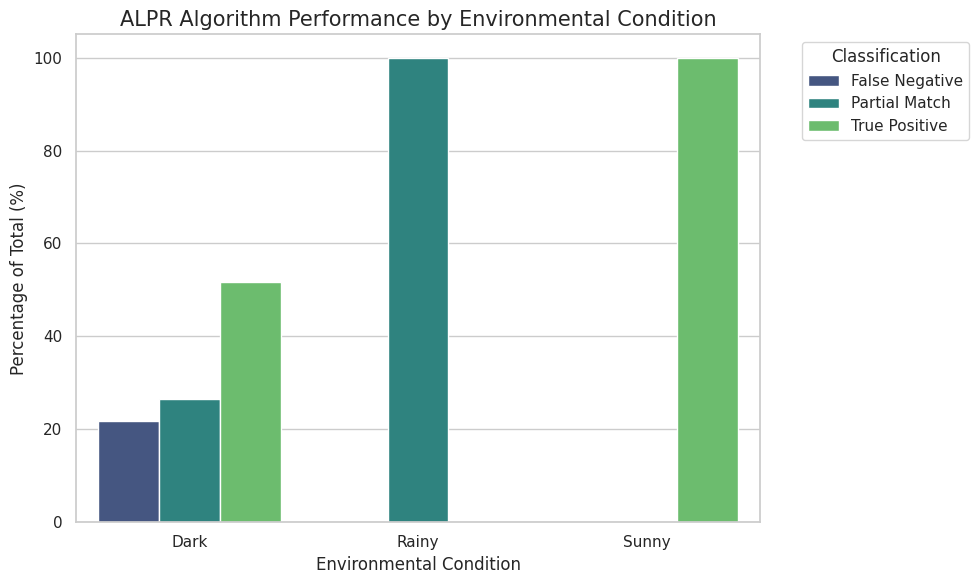

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set(style="whitegrid")

# Prepare data for visualization
# We use the condition_analysis dataframe created in the previous step
plot_data = condition_analysis.reset_index().melt(id_vars='Condition', var_name='Classification', value_name='Percentage')

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Condition', y='Percentage', hue='Classification', palette='viridis')

# Add titles and labels in English for your project
plt.title('ALPR Algorithm Performance by Environmental Condition', fontsize=15)
plt.xlabel('Environmental Condition', fontsize=12)
plt.ylabel('Percentage of Total (%)', fontsize=12)
plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()